# Diabetes Classification Project with Model Training, HPO, Hosting, Endpoint Creation, and Inference via Amazon SageMaker AI

Install an fixed version of sagemaker to ensure compatability with tools used in this notebook. Also installs other needed libraries.

In [1]:
%pip install "sagemaker==2.218.0"
%pip install botocore boto3 awscli matplotlib seaborn pandas bokeh --upgrade

Install all of the necessary imports for this notebook.

In [2]:
# Handle imports
import sagemaker
import json
import pandas as pd
import numpy as np
import boto3

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sagemaker.inputs import TrainingInput
from sagemaker import image_uris
from sagemaker.image_uris import retrieve 

import time
from time import gmtime, strftime, sleep
from pprint import pprint
import bokeh
import bokeh.io
from bokeh.plotting import figure, show
from bokeh.models import HoverTool
import io

import warnings
warnings.filterwarnings('ignore')

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


Define high-level and configuration variables that will be re-used in multiple places.

In [3]:
# Initialize sagemaker-related clients and instances.
sagemaker_session = sagemaker.Session() # create a SageMaker session
s3 = sagemaker_session.boto_session.resource("s3") #creates a resource object for interacting with Amazon S3.

region = boto3.Session().region_name
smclient = boto3.Session().client("sagemaker")
role = sagemaker.get_execution_role()

In [4]:
# Define variables for the file names, bucket names, and prefixes
filename = 'diabetes_unclean.csv'
training_filename = 'diabetes-training-data.csv'
validation_filename = 'diabetes-validation-data.csv'
s3_bucket = 'aigc-training-1668'
training_prefix = 'project2/train'
validation_prefix = 'project2/validation'
output_prefix = 'project2/output'

In [5]:
# Define configuration variables
instance_type = 'ml.m5.xlarge'
xg_version = '1.7-1'

Kaggle: https://www.kaggle.com/datasets/kabirolawalemohammed/diabetes-unclean
The data has been uploaded to an S3 bucket already, so this reads it from the bucket.

In [6]:
df = pd.read_csv(f's3://{s3_bucket}/{filename}')

# Check first five rows of data
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [7]:
# Check data shape and types
print(f"The date has {df.shape[0]} rows and {df.shape[1]} columns")
df.dtypes

The date has 1009 rows and 14 columns


ID             int64
No_Pation      int64
Gender        object
AGE          float64
Urea         float64
Cr           float64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS         object
dtype: object

## Examining Categorial Data

These sections checks if the categorical data are consistent and assess if they require encoding. In this dataset specifically, there are some inconsistenties in the capitalization and spacing of some variables that should be handled during preprocessing.

In [8]:
# Check the values of categorical columns
print(df['Gender'].unique())
print(df['CLASS'].unique())

['F' 'M' 'f']
['N' 'N ' 'P' 'Y' 'Y ']


### Analysis/Visualization 1: Examining Categorical Data
By examining the unique values of the two categorical columns 'Gender' (feature) and 'Class' (target/label), it's clear that the values require some cleanup. For instance, 'F' & 'f' in the 'Gender' column refer to the same category whereas 'N' & 'N ' and 'Y' & 'Y ' in the 'CLASS' column refer to the same categories. Cleanup should first consolidate the discrepancies and then convert them into numeric values for training.

In [9]:
# Check missing values
df.isnull().sum()

ID           0
No_Pation    0
Gender       0
AGE          1
Urea         1
Cr           2
HbA1c        3
Chol         2
TG           2
HDL          1
LDL          2
VLDL         1
BMI          0
CLASS        0
dtype: int64

After examining null values, we see some scattered missing values across different columns. Since the number is quite small overall, we will remove the rows with missing data.

In [10]:
# Check for duplicate rows
df.duplicated().sum()

0

Since there are no duplicate rows, we will not need to process duplicates.

## Identify Outliers & Data Ranges

In [11]:
# Examine various staticstics about numeric columns
df.describe()

,ID,No_Pation,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1009.000000,1.009000e+03,1008.000000,1008.000000,1007.000000,1006.000000,1007.000000,1007.000000,1008.000000,1007.000000,1008.000000,1009.000000
mean,339.161546,2.717448e+05,53.620040,5.131094,68.973188,8.284155,4.863873,2.348769,1.204216,2.610119,1.850595,29.589911
std,239.738169,3.365681e+06,8.740975,2.931136,59.813297,2.533576,1.297326,1.397487,0.658158,1.116095,3.649859,4.946246
min,1.000000,1.230000e+02,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,127.000000,2.406500e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,296.000000,3.439900e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,548.000000,4.539000e+04,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


### Visualization/Analysis 2: Identify Outliers & Data Ranges
Based on the above, we can see that some columns contain values that are more than 3 standard deviations from the mean, which are outliers we should handle.
Noted columns include HbA1c, Cholesterol (Chol),  Triglycerides (TG), High-density lipids (HLD), low-desity lipids (LDL), very-low density lipids (VLDL), and BMI.

The 'No_Pation' and 'ID' columns are both patient identifiers and should be excludedfrom model training and dropped from the dataset since they are not features. That being said, the remaining columns still have some data range differences; we should apply normalization to ensure this does not negatively impact training convergence.

In [12]:
# Drop ID and No_Pation since these are identifiers and not features
df = df.drop(['ID', 'No_Pation'], axis=1)
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## Data Transformation 1: Handling null values

In [13]:
# Since there are very few, drop the null values
df_clean = df.dropna(axis = 0, inplace=False)
df_clean.shape

(994, 12)

## Examine Data Distributions

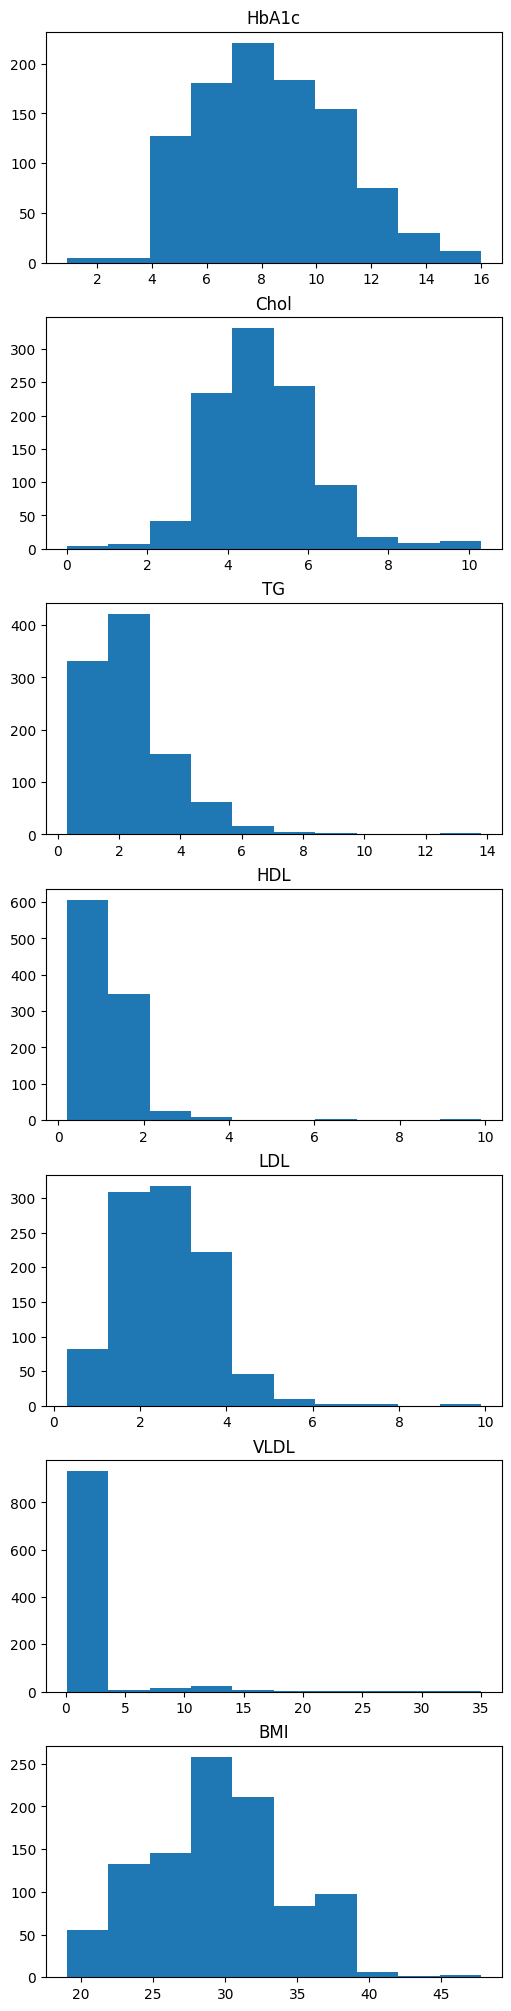

In [14]:
# To determine the best way to handle outliers, visualize the distributions
# HbA1c, Chol, TG, HLD, LDL, VLDL, BMI
outlier_columns = ['HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']

# Define figure config
fig, ax = plt.subplots(7, 1, layout='constrained', figsize=(5,20))

# Fill in subplots
for i in range(len(outlier_columns)):
    ax[i].set_title(outlier_columns[i])
    ax[i].hist(df_clean[outlier_columns[i]])
plt.show()

### Visualization/Analysis 3: Exam Data Distributions
We need to analyze the data distribution to decide which approach to handle outliers. Based on the graphs, the columns 'HbA1c' & 'Chol' are fairly normally distributed, so we can use the z-score method to identify outliers.

Since the other columns are not normally distributed, we can use the IQR instead.

## Data Transformation 2: Handle Outliers

As mentioned from above, apply the z-score method to identify outilers and use capping to address them.

In [15]:
# Use z-score method + capping to handle HbA1c & Chol
threshold = 3

# Get means of the columns
h1c_mean = df_clean['HbA1c'].mean()
chol_mean = df_clean['Chol'].mean()

# Get stadard deviations
h1c_std = df_clean['HbA1c'].std()
chol_std = df_clean['Chol'].std()

# Get boundaries
h1c_upper = h1c_mean + threshold*h1c_std
h1c_lower = h1c_mean - threshold*h1c_std
print(f"The upper and lower boundaries of HbA1c: {h1c_upper} and {h1c_lower}")
chol_upper = chol_mean + threshold*chol_std
chol_lower = chol_mean - threshold*chol_std
print(f"The upper and lower boundaries of Chol: {chol_upper} and {chol_lower}")

# Apply capping
df_clean['HbA1c'] = np.where(df_clean['HbA1c'] > h1c_upper, h1c_upper, df_clean['HbA1c'])
df_clean['HbA1c'] = np.where(df_clean['HbA1c'] < h1c_lower, h1c_lower, df_clean['HbA1c'])
df_clean['Chol'] = np.where(df_clean['Chol'] > chol_upper, chol_upper, df_clean['Chol'])
df_clean['Chol'] = np.where(df_clean['Chol'] < chol_lower, chol_lower, df_clean['Chol'])

# Verify capping has succeeded
h1c_max = df_clean['HbA1c'].max()
h1c_min = df_clean['HbA1c'].min()
chol_max = df_clean['Chol'].max()
chol_min = df_clean['Chol'].min()

print(f"Max and min of HbA1c are {h1c_max} and {h1c_min}")
print(f"Max and min of Chol are {chol_max} and {chol_min}")

The upper and lower boundaries of HbA1c: 15.914112980108825 and 0.6586435591265882
The upper and lower boundaries of Chol: 8.758553454695782 and 0.9608026821251441
Max and min of HbA1c are 15.914112980108825 and 0.9
Max and min of Chol are 8.758553454695782 and 0.9608026821251441


As mentioned from above, apply the IQR method for identifying outliers and capping them.

In [16]:
# Use IQR for columns not normally distributed
# TG, HDL, LDL, VLDL, and BMI

# Get Q1 quantiles
tg_q1 = df_clean['TG'].quantile(0.25)
hdl_q1 = df_clean['HDL'].quantile(0.25)
ldl_q1 = df_clean['LDL'].quantile(0.25)
vldl_q1 = df_clean['VLDL'].quantile(0.25)
bmi_q1 = df_clean['BMI'].quantile(0.25)

# Get Q3 quantiles
tg_q3 = df_clean['TG'].quantile(0.75)
hdl_q3 = df_clean['HDL'].quantile(0.75)
ldl_q3 = df_clean['LDL'].quantile(0.75)
vldl_q3 = df_clean['VLDL'].quantile(0.75)
bmi_q3 = df_clean['BMI'].quantile(0.75)

# Get IQR values
tg_iqr = tg_q3 - tg_q1
hdl_iqr = hdl_q3 - hdl_q1
ldl_iqr = ldl_q3 - ldl_q1
vldl_iqr = vldl_q3 - vldl_q1
bmi_iqr = bmi_q3 - bmi_q1

# Get upper limits
tg_upper = tg_q3 + 1.5*tg_iqr
hdl_upper = hdl_q3 + 1.5*hdl_iqr
ldl_upper = ldl_q3 + 1.5*ldl_iqr
vldl_upper = vldl_q3 + 1.5*vldl_iqr
bmi_upper = bmi_q3 + 1.5*bmi_iqr

# Get lower limits
tg_lower = tg_q3 - 1.5*tg_iqr
hdl_lower = hdl_q3 - 1.5*hdl_iqr
ldl_lower = ldl_q3 - 1.5*ldl_iqr
vldl_lower = vldl_q3 - 1.5*vldl_iqr
bmi_lower = bmi_q3 - 1.5*bmi_iqr

print(f"TG upper/lower boundaries: {tg_upper} and {tg_lower}")
print(f"HDL upper/lower boundaries: {hdl_upper} and {hdl_lower}")
print(f"LDL upper/lower boundaries: {ldl_upper} and {ldl_lower}")
print(f"VLDL upper/lower boundaries: {vldl_upper} and {vldl_lower}")
print(f"BMI upper/lower boundaries: {bmi_upper} and {bmi_lower}")

# Apply capping method
df_clean['TG'] = np.where(df_clean['TG'] > tg_upper, tg_upper, df_clean['TG'])
df_clean['TG'] = np.where(df_clean['TG'] < tg_lower, tg_lower, df_clean['TG'])
df_clean['HDL'] = np.where(df_clean['HDL'] > hdl_upper, hdl_upper, df_clean['HDL'])
df_clean['HDL'] = np.where(df_clean['HDL'] < hdl_lower, hdl_lower, df_clean['HDL'])
df_clean['LDL'] = np.where(df_clean['LDL'] > ldl_upper, ldl_upper, df_clean['LDL'])
df_clean['LDL'] = np.where(df_clean['LDL'] < ldl_lower, ldl_lower, df_clean['LDL'])
df_clean['VLDL'] = np.where(df_clean['VLDL'] > vldl_upper, vldl_upper, df_clean['VLDL'])
df_clean['VLDL'] = np.where(df_clean['VLDL'] < vldl_lower, vldl_lower, df_clean['VLDL'])
df_clean['BMI'] = np.where(df_clean['BMI'] > bmi_upper, bmi_upper, df_clean['BMI'])
df_clean['BMI'] = np.where(df_clean['BMI'] < bmi_lower, bmi_lower, df_clean['BMI'])

# Verify capping
tg_max = df_clean['TG'].max()
tg_min = df_clean['TG'].min()
hdl_max = df_clean['HDL'].max()
hdl_min = df_clean['HDL'].min()
ldl_max = df_clean['LDL'].max()
ldl_min = df_clean['LDL'].min()
vldl_max = df_clean['VLDL'].max()
vldl_min = df_clean['VLDL'].min()
bmi_max = df_clean['BMI'].max()
bmi_min = df_clean['BMI'].min()

print(f"Max and min of TG are {tg_max} and {tg_min}")
print(f"Max and min of HDL are {hdl_max} and {hdl_min}")
print(f"Max and min of LDL are {ldl_max} and {ldl_min}")
print(f"Max and min of VLDL are {vldl_max} and {vldl_min}")
print(f"Max and min of BMI are {bmi_max} and {bmi_min}")

TG upper/lower boundaries: 5.0 and 0.8000000000000003
HDL upper/lower boundaries: 1.9000000000000001 and 0.7
LDL upper/lower boundaries: 5.549999999999999 and 1.0500000000000003
VLDL upper/lower boundaries: 2.7 and 0.2999999999999998
BMI upper/lower boundaries: 43.5 and 22.5
Max and min of TG are 5.0 and 0.8000000000000003
Max and min of HDL are 1.9000000000000001 and 0.7
Max and min of LDL are 5.549999999999999 and 1.0500000000000003
Max and min of VLDL are 2.7 and 0.2999999999999998
Max and min of BMI are 43.5 and 22.5


## Data Transformation 3: Cleaning Categorical Data

Handle the extra whitespaces for some values in the target label, "CLASS"

In [17]:
# Replace with int values
df_clean['CLASS'] = df_clean['CLASS'].replace({
    'N ': 0,
    'N': 0,
    'P': 1,
    'Y ': 2,
    'Y': 2
})

# Verify there should only be 3 classes now.
print(df_clean['CLASS'].unique())

[0 1 2]


Handle the casing issue in the 'Gender' column

In [18]:
# Handle the casing issue in the gender column
df_clean['Gender'] = df['Gender'].str.upper()
df_clean['Gender'].unique()

# One-hot encode the categories; we only need M or F
# since they are dependent on one another
# Due to the data, this model excludes individuals identifying as non-binary
df_clean['M'] = np.where(df_clean['Gender']=='M', 1, 0)

# Drop column since we have completed one-hot encoding.
df_clean = df_clean.drop(columns=['Gender'])

# Check new column
df_clean.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,M
0,50.0,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,0,0
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0,1
2,50.0,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,0,0
3,50.0,4.7,46.0,4.9,4.2,0.9,1.9,1.4,0.5,24.0,0,0
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,22.5,0,1


## Data Transformation 4: Normalizing Data

Some columns such as Age and Cr have much larger values compared to columns like VLDL. This cell aims to normalize the data for preprocessing.

In [19]:
# Set up scaler
scalar = StandardScaler()

# Get non-categorical columns
numerics = ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'HDL', 'LDL', 'VLDL', 'BMI']

# Fit scaler
df_clean[numerics] = scalar.fit_transform(df_clean[numerics])

# Verify transformation
df_clean.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,M
0,-0.411899,-0.145760,-0.378677,-1.332641,-0.519009,0.9,2.211629,-1.176779,-1.022831,-1.212676,0,0
1,-3.153598,-0.213631,-0.112266,-1.332641,-0.917789,1.4,-0.146335,-0.491812,-0.863349,-1.424915,0,1
2,-0.411899,-0.145760,-0.378677,-1.332641,-0.519009,0.9,2.211629,-1.176779,-1.022831,-1.212676,0,0
3,-0.411899,-0.145760,-0.378677,-1.332641,-0.519009,0.9,2.211629,-1.176779,-1.022831,-1.212676,0,0
4,-2.353936,0.668693,-0.378677,-1.332641,0.039283,1.0,-1.030571,-0.589664,-1.182312,-1.531035,0,1


## Correlations

Seaborn pairplot allows us to visualize the relationships between the target label and the features, as well as the features with one another. This sheds light on information such as the estimated strength of correlation and identify potential collinear features. This dataset does not have a lot of features, but datasets with a large volume of features could trim some features (if they are collinear) to reduce processing overhead without impacting the model accuracy.

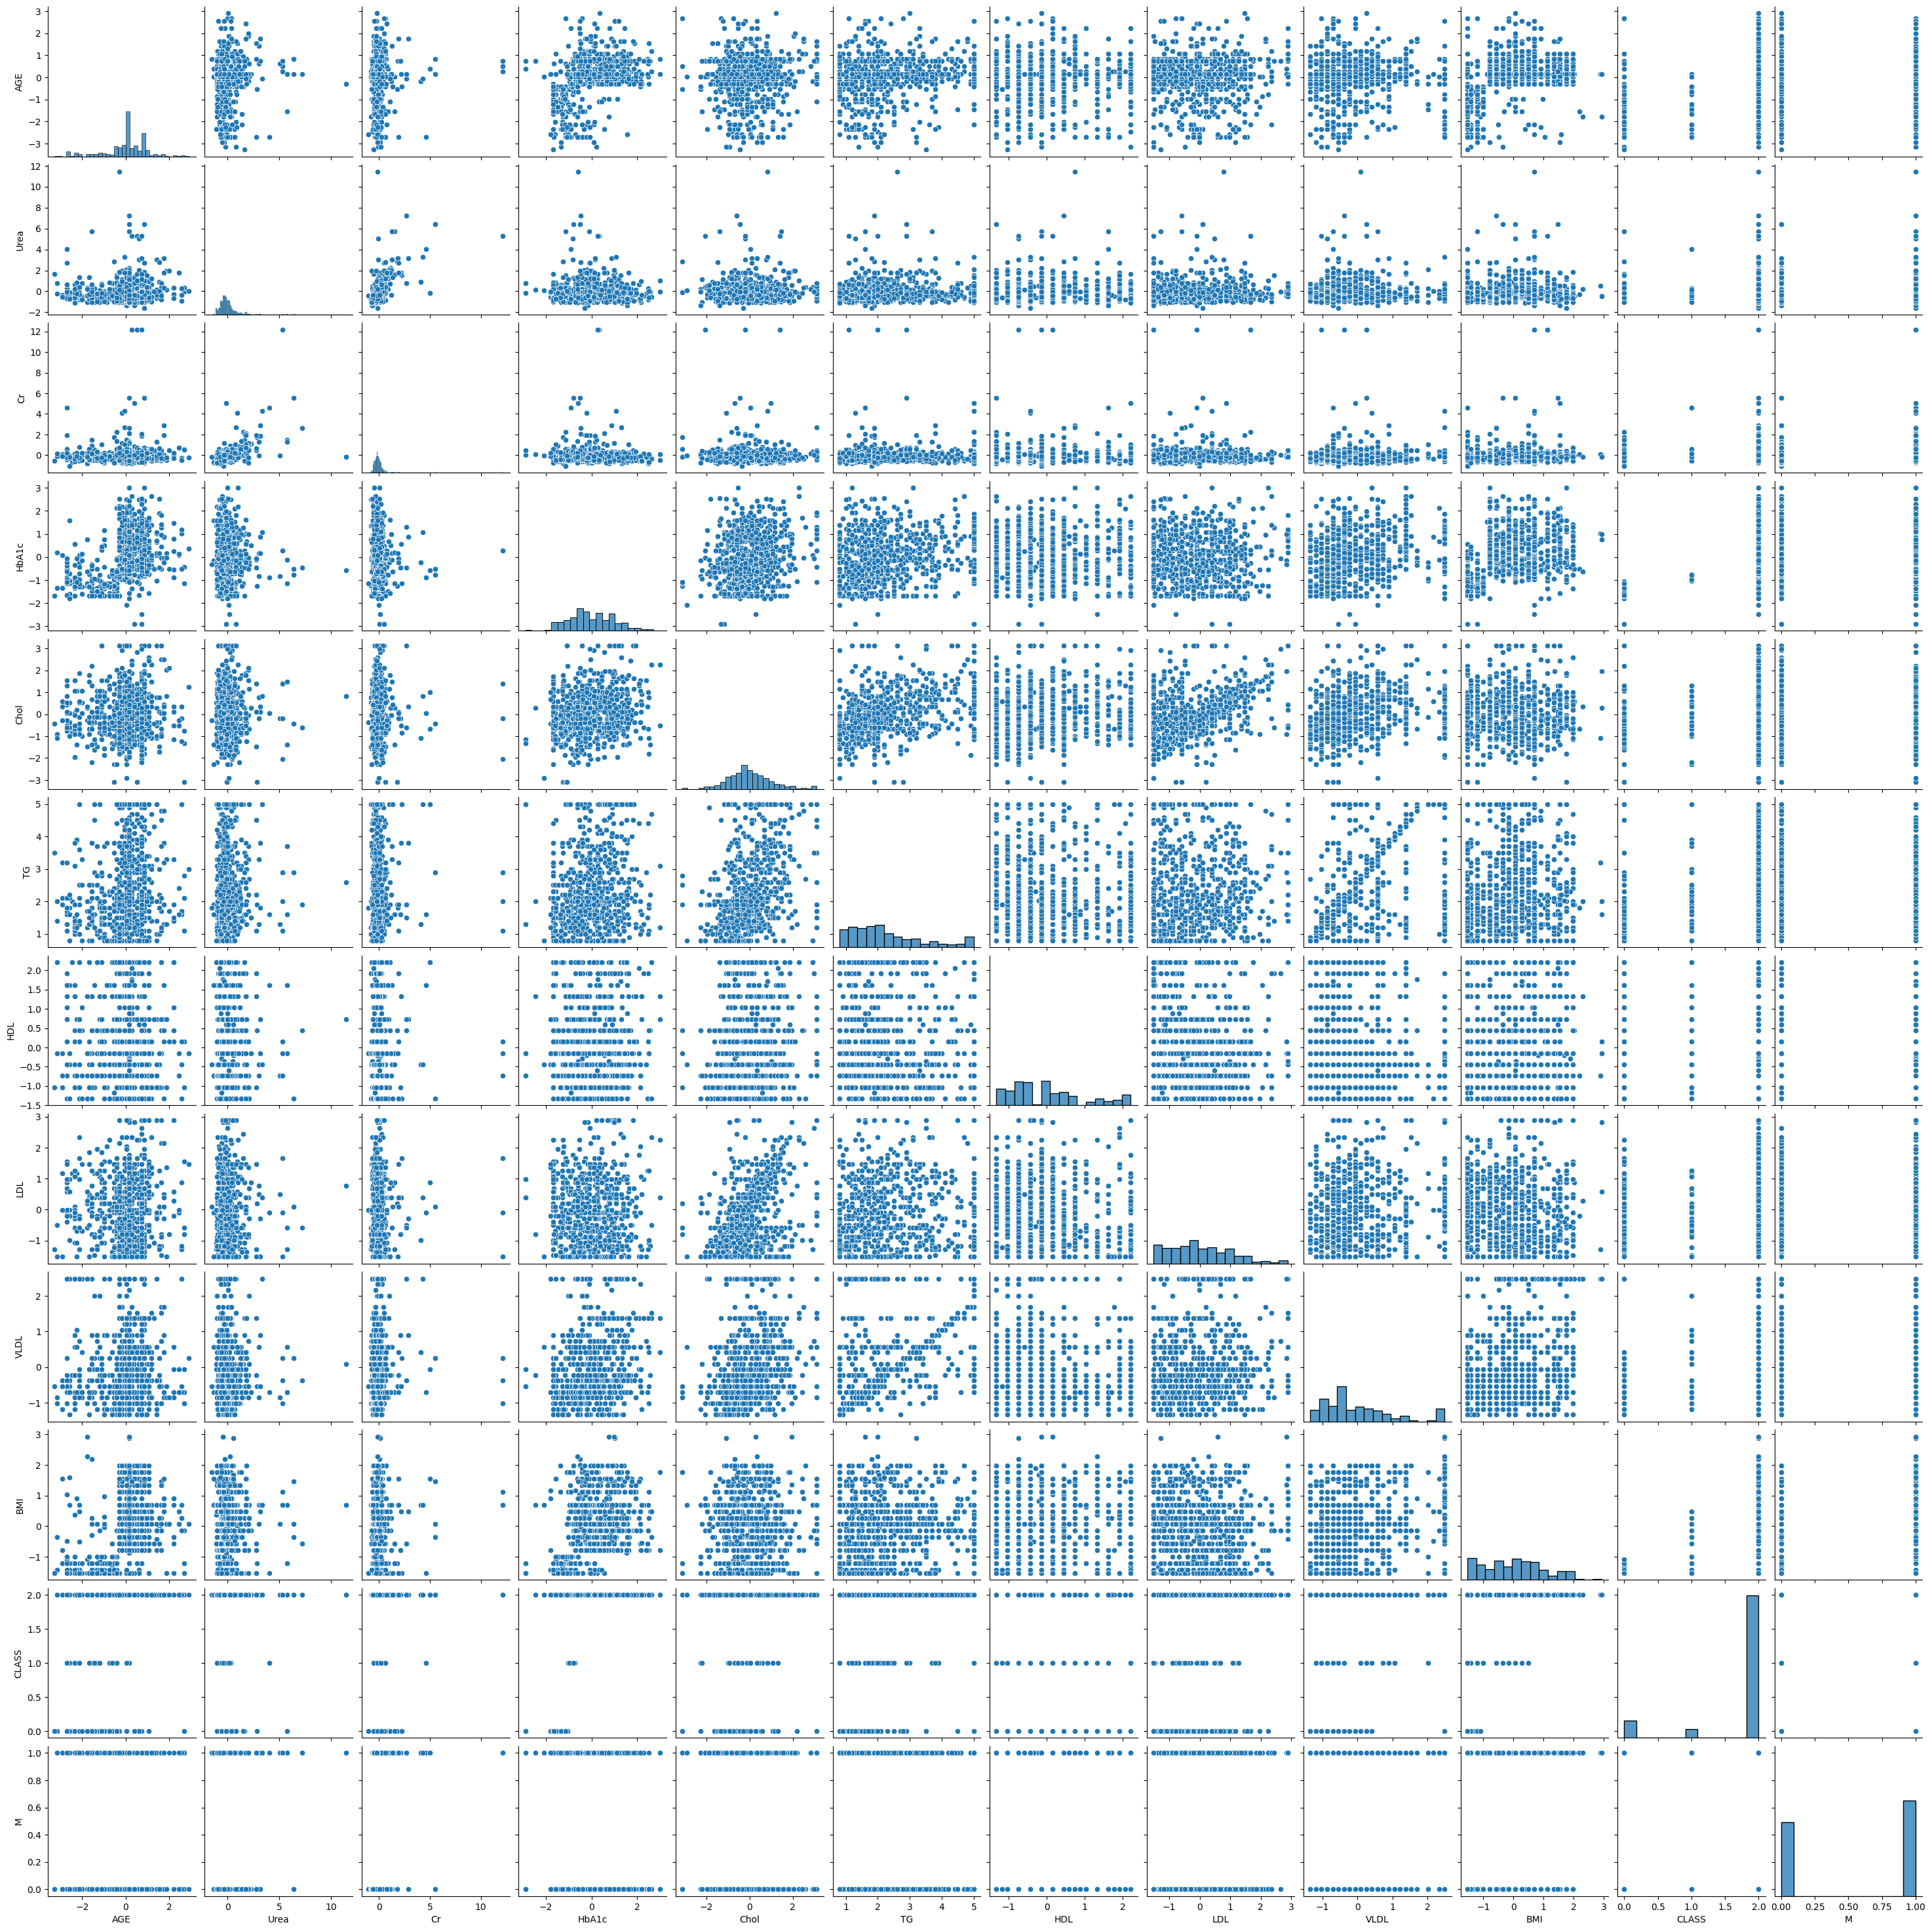

In [20]:
# Visualize the correlation matrix with pairplot
sns.pairplot(df_clean)

Visualize the correlations as a heatmap with values. This provides a different view of the correlations using a combination of colors (coolness/warmness) and the actual correlation value.

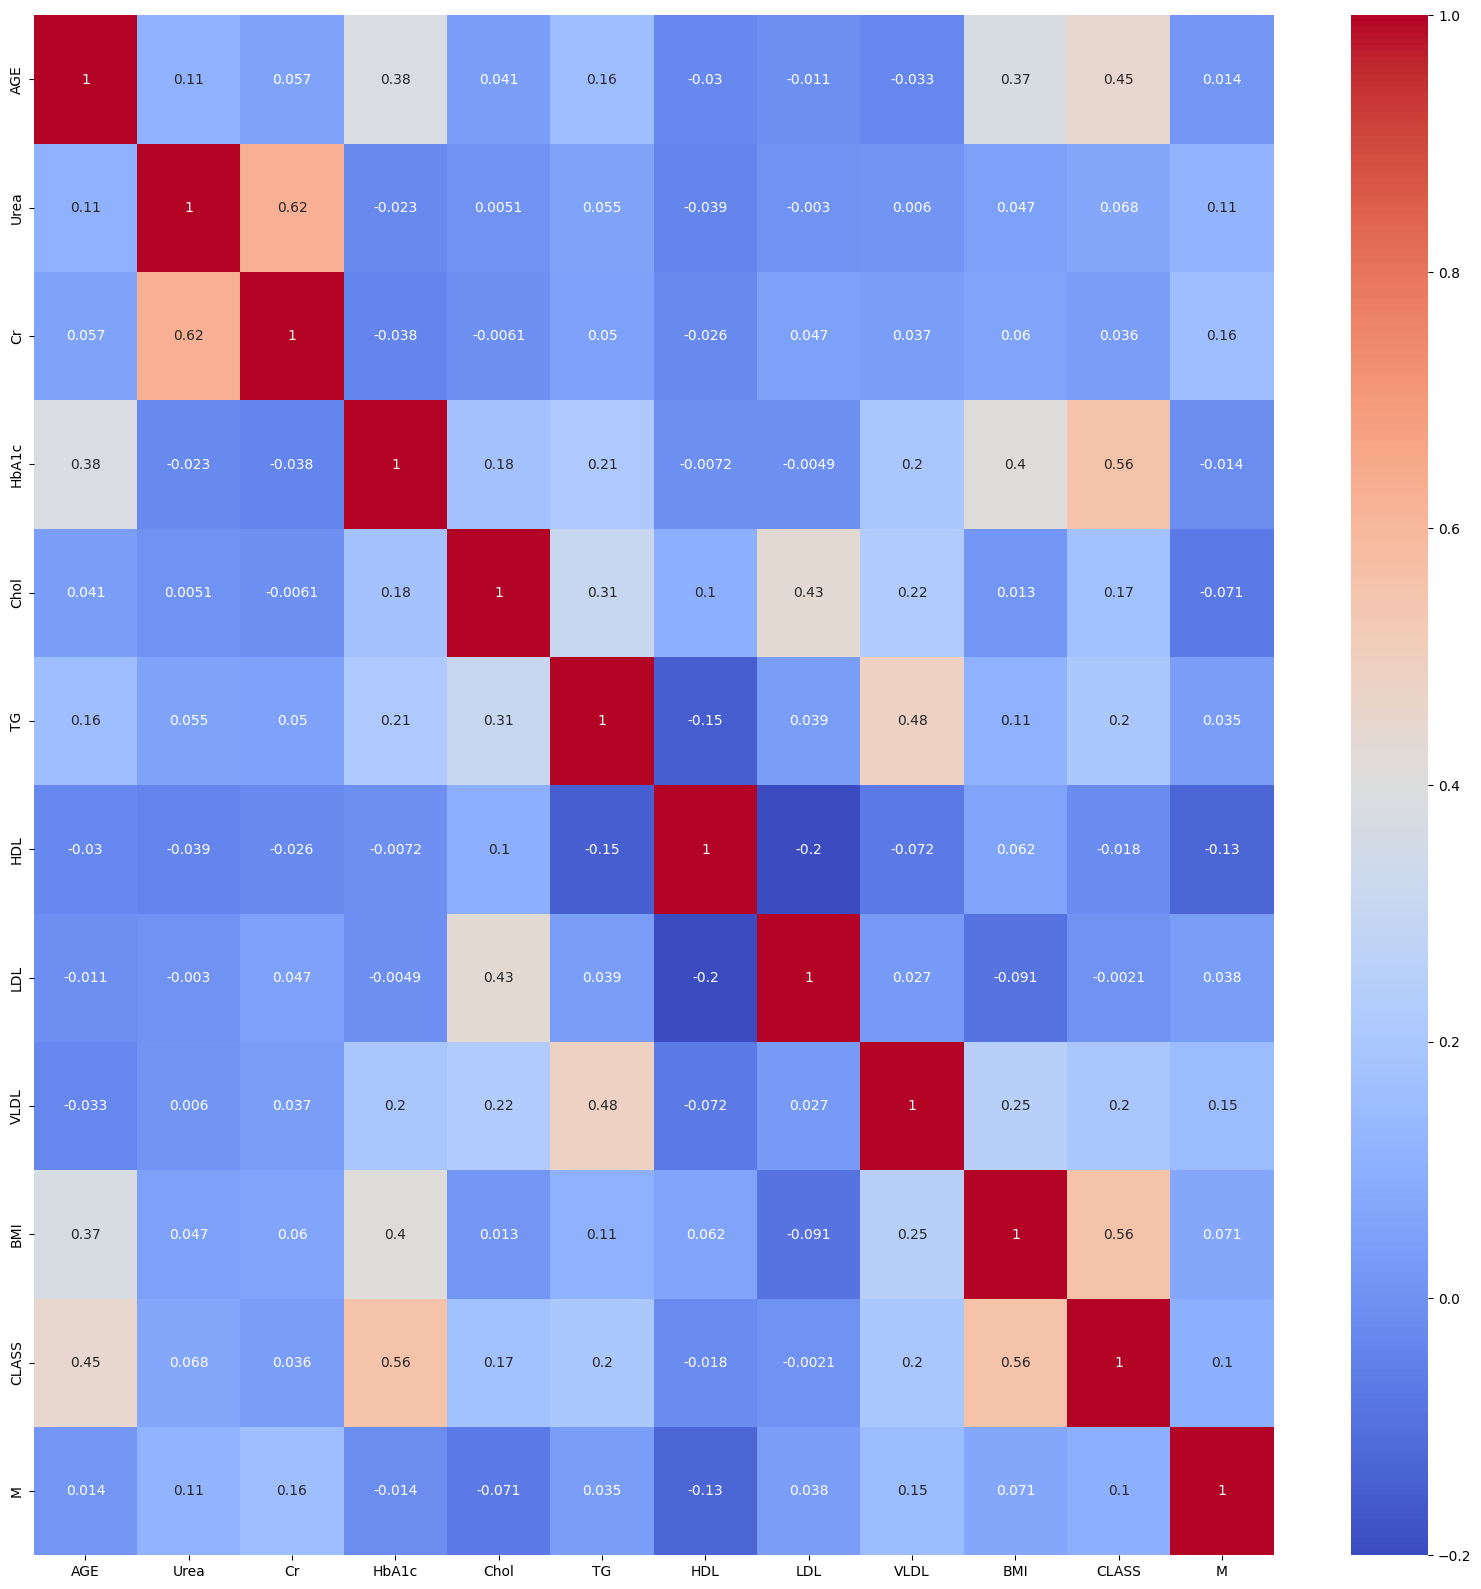

In [21]:
df_corr = df_clean.corr()
plt.figure(figsize=(20,20))

heatmap = sns.heatmap(df_corr, annot=True, cmap="coolwarm")

### Visualization/Analysis 4: Correlation
Based on the preliminary examination, some feature columns do exhibit higher correlation (Urea & Cr: 0.62), but this remains below the threshold for removal consideration (> 0.8).

In addition, it appears that there is a stronger correlation between the target label ('CLASS') and the columns 'AGE,' 'HbA1c,' and 'BMI.' Some of the feature columns ('Urea,' 'Cr,' 'HDL,' 'LDL') have a fairly low correlation values and should be considered for removal upon feature re-engineering.

## Feature Importance

In [22]:
# Separate features from labels.
X = df_clean[['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'M']]
y = df_clean.CLASS

We use ExtraTreesRegressor to analyze feature importance. This algorithm uses a randomization technique that does not act greedy; this leads to faster training speed, higher diversity of trees, and less risk of overfitting.

In [23]:
model = ExtraTreesRegressor()
model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [24]:
print(model.feature_importances_)

[0.08738471 0.01184581 0.0106694  0.27379783 0.0756438  0.03936192
 0.01156685 0.01814499 0.02945608 0.43104093 0.01108768]


In [25]:
print(X.columns)

Index(['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI',
       'M'],
      dtype='object')


### Visualization/Analysis 5: Feature Importance
Based on the preliminary analysis of the model weights, it appears that the columns 'HbA1c,' and 'BMI' are heavily-weighted as expected. Some columns ('Urea,' 'Cr,' 'HDL,' 'LDL') have fairly low weights and may be considered for removal during the feature re-engineering process.

### Data splitting
This cell splits the original dataset by a 70/30 ratio; of the 70 percent, 10% will further be split and used as the validation data.
The training and validation sets will be used during the model training steps, whereas the testing data will be used for the final verification.

In [26]:
# Split data into 70/30 for training/testing
X_training, X_test, y_training, y_test = train_test_split(X, y, test_size=0.3, random_state=498)

# Split the training data into 90/10 for training/validation
X_train, X_val, y_train, y_val = train_test_split(X_training, y_training, test_size=0.1, random_state=498)

# Verify the shapes of the train, val, and test data
print(f"The final training set has {X_train.shape[0]} rows")
print(f"The final validation set has {X_val.shape[0]} rows")
print(f"The final testing set has {X_test.shape[0]} rows")

The final training set has 625 rows
The final validation set has 70 rows
The final testing set has 299 rows


In [27]:
# Prepare the training data for storage in S3
training_data = pd.concat([y_train, X_train], axis=1)

# Prepare the validation data for storage in S3
validation_data = pd.concat([y_val, X_val], axis=1)

In [28]:
# Save training and validation files into file system
training_data.to_csv(training_filename, header=False, index=False)
validation_data.to_csv(validation_filename, header=False, index=False)

In [29]:
# Upload the files to respective S3 bucket folders
!aws s3 cp diabetes-training-data.csv s3://{s3_bucket}/{training_prefix}/{training_filename}
!aws s3 cp diabetes-validation-data.csv s3://{s3_bucket}/{validation_prefix}/{validation_filename}

upload: ./diabetes-training-data.csv to s3://aigc-training-1668/project2/train/diabetes-training-data.csv
upload: ./diabetes-validation-data.csv to s3://aigc-training-1668/project2/validation/diabetes-validation-data.csv


In [30]:
# Define input and output locations
training_s3_input_location = f"s3://{s3_bucket}/{training_prefix}/{training_filename}"
validation_s3_input_location = f"s3://{s3_bucket}/{validation_prefix}/{validation_filename}"
training_s3_output_location = f"s3://{s3_bucket}/{output_prefix}/"

In [31]:
# Prepare training and validation inputs
train_input = TrainingInput(training_s3_input_location, content_type="text/csv")
val_input = TrainingInput(validation_s3_input_location, content_type="text/csv")

In [32]:
# XGBoost has good support for multi-class classification.
# Prepare image URL for XGBoost Algorithm
image_container = retrieve('xgboost', region, xg_version)
image_container

'683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1'

In [33]:
# Set up estimator to define the infrastructure requirements for future training job
estimator = sagemaker.estimator.Estimator(
    image_container,
    role,
    instance_count=1,
    instance_type=instance_type,
    output_path=training_s3_output_location,
    sagemaker_session=sagemaker_session
)

In [34]:
# Set up the hyperparameters for three classes
# Changing to merror metric since this calculates multi-class classification accuracy
estimator.set_hyperparameters(
    objective='multi:softprob',
    num_class=3,
    num_round=100,
    eval_metric='mlogloss'
)

# Model Training
Complete a training job using XGBoost. We will select the same evaluation metric to compare it to the one discovered in the hyperparameter tuning job. The softprob paramater will return the probability of each class being the correct answer (three in this case), and mlogloss is the recommended evaluation metric for the softprob objective, or there might be a dimension mismatch.

In [35]:
# Create the training job with both training and validation data
estimator.fit({'train': train_input, 'validation': val_input})

INFO:sagemaker:Creating training-job with name: sagemaker-xgboost-2026-04-07-23-08-35-855


2026-04-07 23:08:37 Starting - Starting the training job...
2026-04-07 23:08:53 Starting - Preparing the instances for training...
2026-04-07 23:09:16 Downloading - Downloading input data...
2026-04-07 23:09:41 Downloading - Downloading the training image...
2026-04-07 23:10:32 Training - Training image download completed. Training in progress../miniconda3/lib/python3.9/site-packages/sagemaker_containers/_server.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-04-07 23:10:40.016 ip-10-0-76-174.ec2.internal:7 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2026-04-07 23:10:40.083 ip-10-0-76-174.ec2.internal:7 INFO profiler_config_parser.py:111] User has disabled profiler.
[2026-04-07:23:10:40:INFO] Imported framework sagemaker_xgboost_container.training
[

In [36]:
# Check estimator object information
estimator.__dict__

{'image_uri': '683313688378.dkr.ecr.us-east-1.amazonaws.com/sagemaker-xgboost:1.7-1',
 '_hyperparameters': {'objective': 'multi:softprob',
  'num_class': 3,
  'num_round': 100,
  'eval_metric': 'mlogloss'},
 'instance_count': 1,
 'instance_type': 'ml.m5.xlarge',
 'keep_alive_period_in_seconds': None,
 'instance_groups': None,
 'volume_size': 30,
 'max_run': 86400,
 'input_mode': 'File',
 'metric_definitions': None,
 'model_uri': None,
 'model_channel_name': 'model',
 'code_uri': None,
 'code_channel_name': 'code',
 'source_dir': None,
 'git_config': None,
 'container_log_level': 20,
 'code_location': None,
 'entry_point': None,
 'dependencies': [],
 'uploaded_code': None,
 'sagemaker_session': <sagemaker.session.Session at 0x7f51ad7eb3b0>,
 'tags': None,
 'base_job_name': 'sagemaker-xgboost',
 '_current_job_name': 'sagemaker-xgboost-2026-04-07-23-08-35-855',
 'output_path': 's3://aigc-training-1668/project2/output/',
 'latest_training_job': <sagemaker.estimator._TrainingJob at 0x7f519f

In [71]:
# Extract job name to get more information.
single_job_name = estimator._current_job_name
single_job_name

'sagemaker-xgboost-2026-04-07-23-08-35-855'

In [66]:
# Get training job analytics to check evaluation metric.
from sagemaker.analytics import TrainingJobAnalytics
analytics = TrainingJobAnalytics(single_job_name)

In [68]:
# See final entry of evaluation metric.
df = analytics.dataframe()
df.tail(1)

,timestamp,metric_name,value
1,0.0,validation:mlogloss,0.02346


# Hyperparameter Tuning
Conduct hyperparameter tuning to identify the best model given the current ranges of parameters. We will use the best model and compare it to the original trained model.

The cell below defines the hyperparameter tuning job configurations. For this tuning job, we will only define continuous and integer parameters.

In [37]:
tuning_job_name = "xgboost-tuningjob-" + strftime("%d-%H-%M-%S", gmtime())

print(tuning_job_name)

tuning_job_config = {
    "ParameterRanges": {
        "CategoricalParameterRanges": [],
        "ContinuousParameterRanges": [
            {
                "MaxValue": "1",
                "MinValue": "0",
                "Name": "eta",
            },
            {
                "MaxValue": "10",
                "MinValue": "1",
                "Name": "min_child_weight",
            },
            {
                "MaxValue": "2",
                "MinValue": "0",
                "Name": "alpha",
            },
        ],
        "IntegerParameterRanges": [
            {
                "MaxValue": "10",
                "MinValue": "1",
                "Name": "max_depth",
            }
        ],
    },
    "ResourceLimits": {"MaxNumberOfTrainingJobs": 10, "MaxParallelTrainingJobs": 3},
    "Strategy": "Bayesian",
    "HyperParameterTuningJobObjective": {"MetricName": "validation:mlogloss", "Type": "Minimize"},
}

xgboost-tuningjob-07-23-11-23


This section defines the training job configurations that will be used in tandem with the hyperparameter tuning configurations. The static parameters will define the configuration for the algorithm (XGBoost in this case). Since the dataset contains three classes, we will use three classes. The objective and evaluation metrics are selected to match the previously-trained model.

In [38]:
training_image = retrieve(framework="xgboost", region=region, version=xg_version)

s3_input_train = "s3://{}/{}/".format(s3_bucket, training_prefix)
s3_input_validation = "s3://{}/{}/".format(s3_bucket, validation_prefix)

training_job_definition = {
    "AlgorithmSpecification": {"TrainingImage": training_image, "TrainingInputMode": "File"},
    "InputDataConfig": [
        {
            "ChannelName": "train",
            "CompressionType": "None",
            "ContentType": "csv",
            "DataSource": {
                "S3DataSource": {
                    "S3DataDistributionType": "FullyReplicated",
                    "S3DataType": "S3Prefix",
                    "S3Uri": s3_input_train,
                }
            },
        },
        {
            "ChannelName": "validation",
            "CompressionType": "None",
            "ContentType": "csv",
            "DataSource": {
                "S3DataSource": {
                    "S3DataDistributionType": "FullyReplicated",
                    "S3DataType": "S3Prefix",
                    "S3Uri": s3_input_validation,
                }
            },
        },
    ],
    "OutputDataConfig": {"S3OutputPath": "s3://{}/{}/output".format(s3_bucket, output_prefix)},
    "ResourceConfig": {"InstanceCount": 1, "InstanceType": instance_type, "VolumeSizeInGB": 10},
    "RoleArn": role,
    "StaticHyperParameters": {
        "eval_metric": "mlogloss",
        "num_round": "30",
        "objective": "multi:softprob",
        "num_class": "3",
        "rate_drop": "0.3",
        "tweedie_variance_power": "1.4",
    },
    "StoppingCondition": {"MaxRuntimeInSeconds": 43200},
}

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


This cell runs the hyperparameter tuning job using Amazon Sagemaker AI using the tuning and training job configuration/definitions.

In [39]:
# Initiate tuning job in Sagemaker AI
smclient.create_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuning_job_name,
    HyperParameterTuningJobConfig=tuning_job_config,
    TrainingJobDefinition=training_job_definition,
)

{'HyperParameterTuningJobArn': 'arn:aws:sagemaker:us-east-1:152554489613:hyper-parameter-tuning-job/xgboost-tuningjob-07-23-11-23',
 'ResponseMetadata': {'RequestId': '78de76fa-7238-45f5-b550-bfcc9ea8b440',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amzn-requestid': '78de76fa-7238-45f5-b550-bfcc9ea8b440',
   'strict-transport-security': 'max-age=47304000; includeSubDomains',
   'x-frame-options': 'DENY',
   'content-security-policy': "frame-ancestors 'none'",
   'cache-control': 'no-cache, no-store, must-revalidate',
   'x-content-type-options': 'nosniff',
   'content-type': 'application/x-amz-json-1.1',
   'content-length': '130',
   'date': 'Tue, 07 Apr 2026 23:11:24 GMT'},
  'RetryAttempts': 0}}

In [45]:
# Describe the state of the tuning job.
smclient.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=tuning_job_name)[
    "HyperParameterTuningJobStatus"
]

'Completed'

In [46]:
# Describe the name of the tuning job.
smclient.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=tuning_job_name)['HyperParameterTuningJobName']

'xgboost-tuningjob-07-23-11-23'

In [47]:
# run this cell to check current status of hyperparameter tuning job
tuning_job_result = smclient.describe_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=tuning_job_name
)

status = tuning_job_result["HyperParameterTuningJobStatus"]
if status != "Completed":
    print("Reminder: the tuning job has not been completed.")

job_count = tuning_job_result["TrainingJobStatusCounters"]["Completed"]
print("%d training jobs have completed" % job_count)

objective = tuning_job_result["HyperParameterTuningJobConfig"]["HyperParameterTuningJobObjective"]
is_minimize = objective["Type"] != "Maximize"
objective_name = objective["MetricName"]

10 training jobs have completed


Run this cell to identify the best training job so far based on the evaluation metric specified for the training jobs.


In [48]:
if tuning_job_result.get("BestTrainingJob", None):
    print("Best model found so far:")
    pprint(tuning_job_result["BestTrainingJob"])
else:
    print("No training jobs have reported results yet.")

Best model found so far:
{'CreationTime': datetime.datetime(2026, 4, 7, 23, 14, 42, tzinfo=tzlocal()),
 'FinalHyperParameterTuningJobObjectiveMetric': {'MetricName': 'validation:mlogloss',
                                                 'Value': 0.02517000027000904},
 'ObjectiveStatus': 'Succeeded',
 'TrainingEndTime': datetime.datetime(2026, 4, 7, 23, 15, 18, tzinfo=tzlocal()),
 'TrainingJobArn': 'arn:aws:sagemaker:us-east-1:152554489613:training-job/xgboost-tuningjob-07-23-11-23-007-211ec547',
 'TrainingJobName': 'xgboost-tuningjob-07-23-11-23-007-211ec547',
 'TrainingJobStatus': 'Completed',
 'TrainingStartTime': datetime.datetime(2026, 4, 7, 23, 14, 49, tzinfo=tzlocal()),
 'TunedHyperParameters': {'alpha': '0.6424730061985395',
                          'eta': '0.7791095807545321',
                          'max_depth': '8',
                          'min_child_weight': '4.954317400861412'}}


In [49]:
# Get job name of best job
xg_job = tuning_job_result["BestTrainingJob"]["TrainingJobName"]
xg_job

'xgboost-tuningjob-07-23-11-23-007-211ec547'

The following cell retrieves the values of the training jobs completed as part of the hyperparameter tuning job to allow tabular comparison.

In [50]:
tuner = sagemaker.HyperparameterTuningJobAnalytics(tuning_job_name)

full_df = tuner.dataframe()

if len(full_df) > 0:
    df = full_df[full_df["FinalObjectiveValue"] > -float("inf")]
    if len(df) > 0:
        df = df.sort_values("FinalObjectiveValue", ascending=is_minimize)
        print("Number of training jobs with valid objective: %d" % len(df))
        print({"lowest": min(df["FinalObjectiveValue"]), "highest": max(df["FinalObjectiveValue"])})
        pd.set_option("display.max_colwidth", None)  # Don't truncate TrainingJobName
    else:
        print("No training jobs have reported valid results yet.")

full_df

Number of training jobs with valid objective: 10
{'lowest': 0.02517000027000904, 'highest': 0.048920001834630966}


,alpha,eta,max_depth,min_child_weight,TrainingJobName,TrainingJobStatus,FinalObjectiveValue,TrainingStartTime,TrainingEndTime,TrainingElapsedTimeSeconds
0,0.198120,0.797255,3.0,5.130098,xgboost-tuningjob-07-23-11-23-010-41c337d9,Completed,0.02676,2026-04-07 23:15:33+00:00,2026-04-07 23:16:02+00:00,29.0
1,1.662595,0.587940,4.0,5.306496,xgboost-tuningjob-07-23-11-23-009-b9d0b013,Completed,0.02945,2026-04-07 23:15:13+00:00,2026-04-07 23:15:42+00:00,29.0
2,1.735947,0.979884,8.0,5.016180,xgboost-tuningjob-07-23-11-23-008-5e8eaf2c,Completed,0.02844,2026-04-07 23:15:02+00:00,2026-04-07 23:15:31+00:00,29.0
3,0.642473,0.779110,8.0,4.954317,xgboost-tuningjob-07-23-11-23-007-211ec547,Completed,0.02517,2026-04-07 23:14:49+00:00,2026-04-07 23:15:18+00:00,29.0
4,0.098131,0.733458,3.0,7.772033,xgboost-tuningjob-07-23-11-23-006-3546b212,Completed,0.04007,2026-04-07 23:14:14+00:00,2026-04-07 23:14:43+00:00,29.0
5,1.424158,0.411617,5.0,5.048357,xgboost-tuningjob-07-23-11-23-005-795468e5,Completed,0.02681,2026-04-07 23:14:19+00:00,2026-04-07 23:14:53+00:00,34.0
6,1.890385,0.313821,3.0,9.811483,xgboost-tuningjob-07-23-11-23-004-e66f18bc,Completed,0.04892,2026-04-07 23:14:02+00:00,2026-04-07 23:14:31+00:00,29.0
7,0.367908,0.784157,9.0,9.734512,xgboost-tuningjob-07-23-11-23-003-6141e227,Completed,0.04561,2026-04-07 23:12:09+00:00,2026-04-07 23:13:53+00:00,104.0
8,0.316965,0.659606,1.0,3.347913,xgboost-tuningjob-07-23-11-23-002-2bc27312,Completed,0.04009,2026-04-07 23:12:09+00:00,2026-04-07 23:13:49+00:00,100.0
9,1.411664,0.553463,9.0,4.990776,xgboost-tuningjob-07-23-11-23-001-f213ad00,Completed,0.02765,2026-04-07 23:12:10+00:00,2026-04-07 23:13:55+00:00,105.0


Wrapper class to leverage Hover to visualize the correlation between the final objective value and other attributes of each training job done as part of the hyperparameter tuning job.

In [51]:
bokeh.io.output_notebook()
class HoverHelper:
    def __init__(self, tuning_analytics):
        self.tuner = tuning_analytics

    def hovertool(self):
        tooltips = [
            ("FinalObjectiveValue", "@FinalObjectiveValue"),
            ("TrainingJobName", "@TrainingJobName"),
        ]
        for k in self.tuner.tuning_ranges.keys():
            tooltips.append((k, "@{%s}" % k))

        ht = HoverTool(tooltips=tooltips)
        return ht

    def tools(self, standard_tools="pan,crosshair,wheel_zoom,zoom_in,zoom_out,undo,reset"):
        return [self.hovertool(), standard_tools]

Loading BokehJS ...

Leverages hover wapper class to visualize the relationship between each training job and their final objective values.

In [52]:
hover = HoverHelper(tuner)

p = figure(width=900, height=400, tools=hover.tools(), x_axis_type="datetime")
p.scatter(source=df, x="TrainingStartTime", y="FinalObjectiveValue",  marker="circle", size=10)
show(p)

This cell leverages the Wrapper Hover class to help visualize the relatioship between the final objective value and each of the four hyperparameters assessed during the tuning job. This might shed some insight on how certain values might correlate with a higher/lower final objective value, allowing us to select more optimized parameter choices.

In [53]:
ranges = tuner.tuning_ranges
figures = []
for hp_name, hp_range in ranges.items():
    categorical_args = {}
    if hp_range.get("Values"):
        # This is marked as categorical.  Check if all options are actually numbers.
        def is_num(x):
            try:
                float(x)
                return 1
            except:
                return 0

        vals = hp_range["Values"]
        if sum([is_num(x) for x in vals]) == len(vals):
            # Bokeh has issues plotting a "categorical" range that's actually numeric, so plot as numeric
            print("Hyperparameter %s is tuned as categorical, but all values are numeric" % hp_name)
        else:
            # Set up extra options for plotting categoricals.  A bit tricky when they're actually numbers.
            categorical_args["x_range"] = vals

    # Now plot it
    p = figure(
        width=500,
        height=500,
        title="Objective vs %s" % hp_name,
        tools=hover.tools(),
        x_axis_label=hp_name,
        y_axis_label=objective_name,
        **categorical_args,
    )
    p.scatter(source=df, x=hp_name, y="FinalObjectiveValue", marker="circle", size=10)
    figures.append(p)
show(bokeh.layouts.Column(*figures))

# Model Hosting and create endpoint

This cell specifies the XGBoost image container that will be used when hosting the model.

In [54]:
xg_container = image_uris.retrieve(
    region=region,
    framework='xgboost',
    version=xg_version,
    instance_type=instance_type,
    image_scope='training'
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: ml.m5.xlarge.


This cell specifies the hosting container that uses the previously retrieved image and the best training job identified during the hyperparameter tuning.

In [55]:
# Hosting the XGBoost model
xg_hosting_container = {
    "Image": xg_container,
    "ModelDataUrl": smclient.describe_training_job(TrainingJobName=xg_job)["ModelArtifacts"][
        "S3ModelArtifacts"
    ],
}

# Creates the model to host.
xg_model_response = smclient.create_model(
    ModelName=xg_job, ExecutionRoleArn=role, PrimaryContainer=xg_hosting_container
)

print(xg_model_response["ModelArn"])

arn:aws:sagemaker:us-east-1:152554489613:model/xgboost-tuningjob-07-23-11-23-007-211ec547


# Model Inferencing through endpoint

This cell creates the endpoint configurations.

In [56]:
xg_endpoint_config = "P2-xg-endpoint-config-" + time.strftime(
    "%Y-%m-%d-%H-%M-%S", time.gmtime()
)
print(xg_endpoint_config)
xg_endpoint_config_response = smclient.create_endpoint_config(
    EndpointConfigName=xg_endpoint_config,
    ProductionVariants=[
        {
            "InstanceType": instance_type,
            "InitialInstanceCount": 1,
            "ModelName": xg_job,
            "VariantName": "AllTraffic",
        }
    ],
)

print("Endpoint Config Arn: " + xg_endpoint_config_response["EndpointConfigArn"])

P2-xg-endpoint-config-2026-04-07-23-20-42
Endpoint Config Arn: arn:aws:sagemaker:us-east-1:152554489613:endpoint-config/P2-xg-endpoint-config-2026-04-07-23-20-42


This cell creates the actual endpoint that allows clients to send a request to use the best trained model from the tuning job.

In [57]:
%%time

xg_endpoint = "P2-xg-endpoint-" + time.strftime("%Y%m%d%H%M", time.gmtime())
print(xg_endpoint)
xg_endpoint_response = smclient.create_endpoint(
    EndpointName=xg_endpoint, EndpointConfigName=xg_endpoint_config
)
print(xg_endpoint_response["EndpointArn"])

resp = smclient.describe_endpoint(EndpointName=xg_endpoint)
status = resp["EndpointStatus"]
print("Status: " + status)

smclient.get_waiter("endpoint_in_service").wait(EndpointName=xg_endpoint)

resp = smclient.describe_endpoint(EndpointName=xg_endpoint)
status = resp["EndpointStatus"]
print("Arn: " + resp["EndpointArn"])
print("Status: " + status)

if status != "InService":
    raise Exception("Endpoint creation did not succeed")

P2-xg-endpoint-202604072320
arn:aws:sagemaker:us-east-1:152554489613:endpoint/P2-xg-endpoint-202604072320
Status: Creating
Arn: arn:aws:sagemaker:us-east-1:152554489613:endpoint/P2-xg-endpoint-202604072320
Status: InService
CPU times: user 48 ms, sys: 4.49 ms, total: 52.5 ms
Wall time: 3min 31s


In [58]:
def np2csv(arr):
    csv = io.BytesIO() #the function gets an array (Numpy array) and creates an in-memory binary buffer named csv
    np.savetxt(csv, arr, delimiter=",", fmt="%g") # write the array 'arr' to csv object, columns should be seperated by commas. The fmt="%g" removes unneccesary decimals when saving and use scientific notation.
    # In the following line:
    # csv.getvalue() retrieves the entire contents of the buffer csv as a byte string.
    # .decode() converts the byte string into a normal Python string by decoding it using the default UTF-8 encoding.
    #.rstrip() removes any trailing whitespace or newlines from the end of the string.
    return csv.getvalue().decode().rstrip()

This cell sends a request to the endpoint created and gets the list of prediction outputs made by the model attached to that endpoint.

In [59]:
%%time

runtime = boto3.client("runtime.sagemaker")

payload = np2csv(X_test)

response = runtime.invoke_endpoint(
    EndpointName=xg_endpoint, ContentType="text/csv", Body=payload
)

result = response["Body"].read().decode()

class_string = [x.split(",") for x in result.split()]
classifications = []
for res in class_string:
    classifications.append(res.index(max(res)))

xg_test_pred = np.array(classifications)

CPU times: user 15.5 ms, sys: 3.69 ms, total: 19.2 ms
Wall time: 155 ms


In [60]:
print(xg_test_pred)

[2 2 2 0 2 2 2 2 0 0 0 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 1 1 2 2
 2 2 1 2 2 2 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 2 2 2 2
 2 1 2 0 2 1 0 2 2 2 2 0 2 1 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 0 0 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 0 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2
 2 2 0 1 1 2 2 1 2 2 1 2 2 1 2 2 2 2 2 2 2 1 2 2 2 2 0 2 2 2 2 2 2 2 2 0 2
 2 2 2]


In [61]:
test_mae_linear = np.mean(np.abs(y_test - xg_test_pred)) # Mean Absolute Error (MAE) of the predictions vs real target values.
#The following line calculates the MAE baseline model using a very simple strategy for predictions: 
#it always predicts the median value of the target variable from the training dataset, which is np.median(train_y).
#The idea is to provide a simple comparison to see if the linear model is performing better than a model that always guesses the median value.
test_mae_baseline = np.mean(
    np.abs(y_test - np.median(y_train))
)  

print("Test MAE Baseline :", round(test_mae_baseline, 3))
print("Test MAE Linear:", round(test_mae_linear, 3))

Test MAE Baseline : 0.254
Test MAE Linear: 0.033


In [62]:
y_test

992    2
559    2
357    2
11     0
337    2
      ..
45     0
949    2
742    2
718    2
352    2
Name: CLASS, Length: 299, dtype: int64

In [63]:
# # We sort the train_y values and select the mdedian (if is 0, then we select 0 otherwise 1). Then we generate that 0s or 1s equal
# #to the lenght of test_y. We use this as baseline for test_pred_baseline
test_pred_baseline = np.repeat(np.median(y_train), len(y_test))

# Compare the binary prediction (test_pred_class) with actual outcomes (y_test)
prediction_accuracy = np.mean((y_test == xg_test_pred)) * 100
baseline_accuracy = np.mean((y_test == test_pred_baseline)) * 100

print("Prediction Accuracy:", round(prediction_accuracy, 1), "%")
print("Baseline Accuracy:", round(baseline_accuracy, 1), "%")

Prediction Accuracy: 98.0 %
Baseline Accuracy: 83.6 %


In [64]:
# Delete the endpoint
sm.delete_endpoint(EndpointName=xg_endpoint)